# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [1]:
import numpy as np

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [2]:
arr = np.zeros(10)
arr[4] = 1
arr_2d = arr.reshape(2,5)

print(arr_2d)

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]


### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [3]:
arr = np.arange(10,50)

reversed_arr = arr[::-1]

even_numbers = reversed_arr[reversed_arr % 2 == 0]

print(even_numbers)

[48 46 44 42 40 38 36 34 32 30 28 26 24 22 20 18 16 14 12 10]


### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [4]:
arr = np.arange(9).reshape(3,3)

print(arr)

[[0 1 2]
 [3 4 5]
 [6 7 8]]


### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [5]:
arr = np.random.random((4,3,2))

print(arr.min())
print(arr.max())

0.023198996182490883
0.9136702812102179


### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [6]:
a = np.random.random((6,4))
b = np.random.random((4,3))

result = np.dot(a,b)

print(result)

[[0.38478933 0.9848944  0.86060514]
 [0.51704844 1.27062981 0.79375628]
 [0.23811775 0.71746308 0.29931432]
 [0.71651943 1.49875239 0.96749427]
 [0.7427454  1.8499289  1.3197805 ]
 [0.58380442 0.81864063 0.4203834 ]]


### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [7]:
arr = np.random.random((7,7))

mean = arr.mean()
std = arr.std()

normalized = (arr - mean) / std

print(normalized)

[[-0.97106773  0.2255517  -0.40599077 -0.79066046 -1.09460217 -1.0818347
   0.68487671]
 [ 1.47304486 -1.0391257  -0.97709928 -0.02422162 -1.18665352  1.37337158
   1.71462721]
 [-0.54035543 -0.69687746  1.03125002 -1.22059979  1.17718794  1.11066695
  -0.54757788]
 [-0.88900997  0.04439821 -1.45798288  1.76154698 -0.65500872  1.46420006
   0.64050714]
 [-0.89625407  0.68519623  1.81253104  0.69182646  0.26551782 -1.30278661
   0.82222697]
 [ 0.39356649  0.56411655 -0.76467218 -0.17296908  0.860295    0.17444833
  -1.03044463]
 [ 0.78119462 -1.46722544  0.75081245  0.47610383  0.97079886 -1.51574558
  -1.22109833]]


# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузите датасет Tips из набора датасетов seaborn

In [10]:
tips = sns.load_dataset("tips")

### Посмотрите на первые 5 строчек

In [11]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Узнайте сколько всего строчек и колонок в данных

In [12]:
tips.shape

(244, 7)

### Проверьте есть ли пропуски в данных

In [13]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Посмотрите на распределение числовых признаков

In [14]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### Найдите максимальное значение 'total_bill'

In [15]:
tips["total_bill"].max()

np.float64(50.81)

### Найдите количество курящих людей

In [16]:
tips[tips["smoker"] == "Yes"].shape[0]

93

### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [17]:
tips.groupby("day")["total_bill"].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [18]:
median_bill = tips["total_bill"].median()

filtered = tips[tips["total_bill"] > median_bill]

filtered.groupby("sex")["tip"].mean()

sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [19]:
tips["smoker_binary"] = tips["smoker"].map({"No":0,"Yes":1})

# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

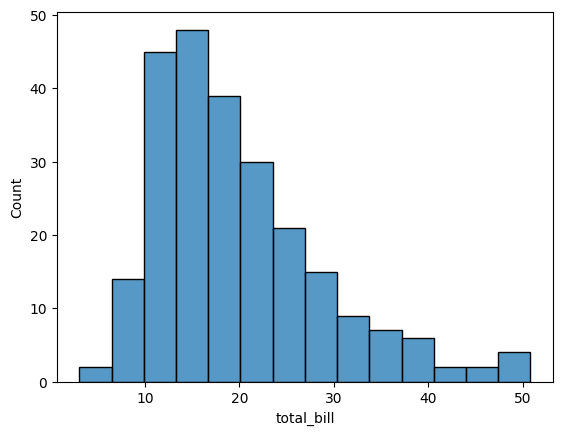

In [20]:
sns.histplot(tips["total_bill"])
plt.show()

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

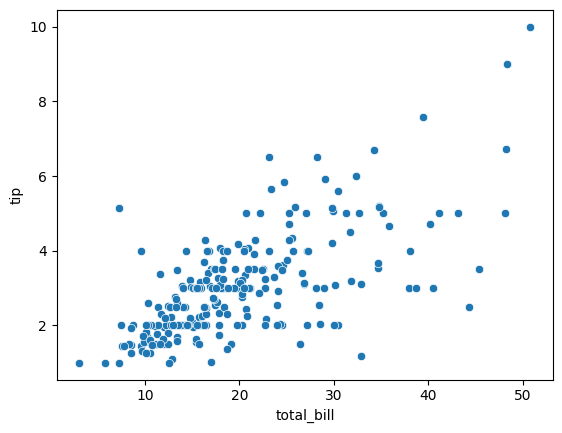

In [21]:
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

### Постройте pairplot

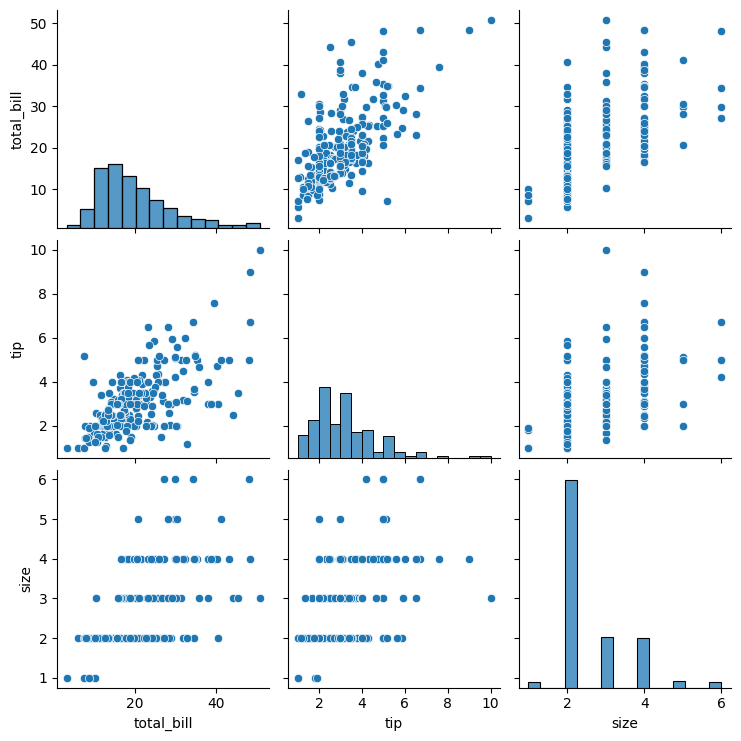

In [22]:
sns.pairplot(tips)
plt.show()

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

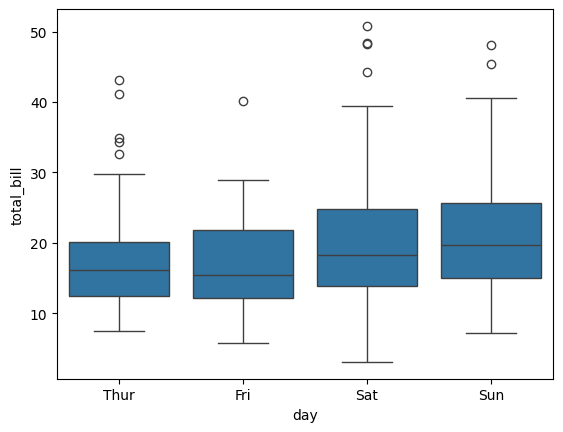

In [23]:
sns.boxplot(x="day", y="total_bill", data=tips)
plt.show()

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

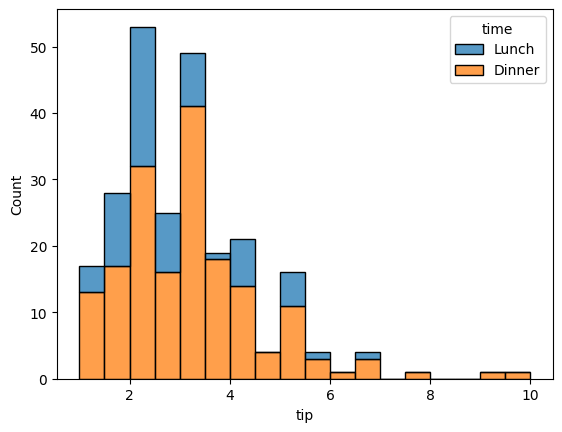

In [24]:
sns.histplot(data=tips, x="tip", hue="time", multiple="stack")
plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

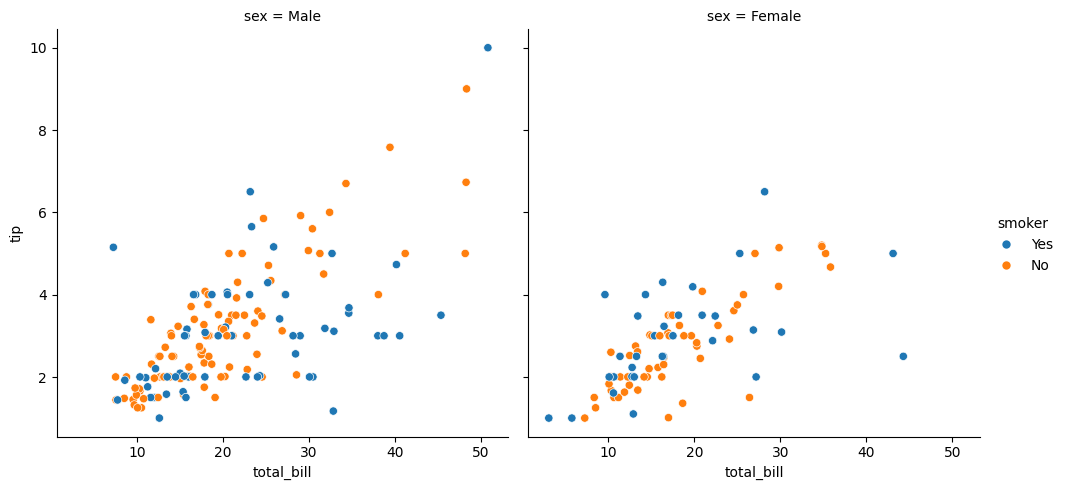

In [25]:
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="sex",
    hue="smoker"
)

plt.show()

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

In [ ]:
""" 
1) распределение total_bill имеет правый хвост, значит большинство чеков небольшие
2) размер чаевых (tip) положительно связан с размером счета
3) в выходные средний чек выше
4) курящие клиенты чаще оставляют чуть больше чаевых

"""